In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("California_Houses.csv")
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568


In [15]:
x = df.drop("Median_House_Value", axis=1)
y = df["Median_House_Value"]

In [17]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3, random_state=42)
x_test,x_val,y_test,y_val = train_test_split(x_test,y_test, test_size=0.5, random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [20]:
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


reg = LinearRegression()
reg.fit(x_train,y_train)
y_pred = reg.predict(x_test)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 4907211997.37478
Mean Absolute Error: 50790.060271050934


In [29]:
input_range = range(0, 1000)

mse_train_list_ridge = []
mse_val_list_ridge = []
mae_train_list_ridge = []
mae_val_list_ridge = []

for i in input_range:
    Ridge_model = Ridge(alpha=i)
    Ridge_model.fit(x_train, y_train)
    y_pred_ridge = Ridge_model.predict(x_val)
    y_pred_ridge_train = Ridge_model.predict(x_train)
    
    mse_val = mean_squared_error(y_val, y_pred_ridge)
    mae_val = mean_absolute_error(y_val, y_pred_ridge)
    
    mse_train = mean_squared_error(y_train, y_pred_ridge_train)
    mae_train = mean_absolute_error(y_train, y_pred_ridge_train)
    
    mse_train_list_ridge.append(mse_train)
    mse_val_list_ridge.append(mse_val)
    mae_train_list_ridge.append(mae_train)
    mae_val_list_ridge.append(mae_val)



In [ ]:
mse_train_list_lasso = []
mse_val_list_lasso = []
mae_train_list_lasso = []
mae_val_list_lasso = []
for i in input_range:
    Lasso_model = Lasso(alpha=i)
    Lasso_model.fit(x_train, y_train)
    y_pred_lasso = Lasso_model.predict(x_val)
    y_pred_lasso_train = Lasso_model.predict(x_train)
    
    mse_val = mean_squared_error(y_val, y_pred_lasso)
    mae_val = mean_absolute_error(y_val, y_pred_lasso)
    
    mse_train = mean_squared_error(y_train, y_pred_lasso_train)
    mae_train = mean_absolute_error(y_train, y_pred_lasso_train)
    
    mse_train_list_lasso.append(mse_train)
    mse_val_list_lasso.append(mse_val)
    mae_train_list_lasso.append(mae_train)
    mae_val_list_lasso.append(mae_val)

In [27]:
def plot_accuracies(ranges, accuracies,num_of_accuracies=1):
    plt.figure(figsize=(30,6))
    for i in range(num_of_accuracies):
        plt.plot(ranges, accuracies[i], marker='o')
        plt.xlabel('Alpha Values')
        plt.ylabel('Error')
    plt.show()

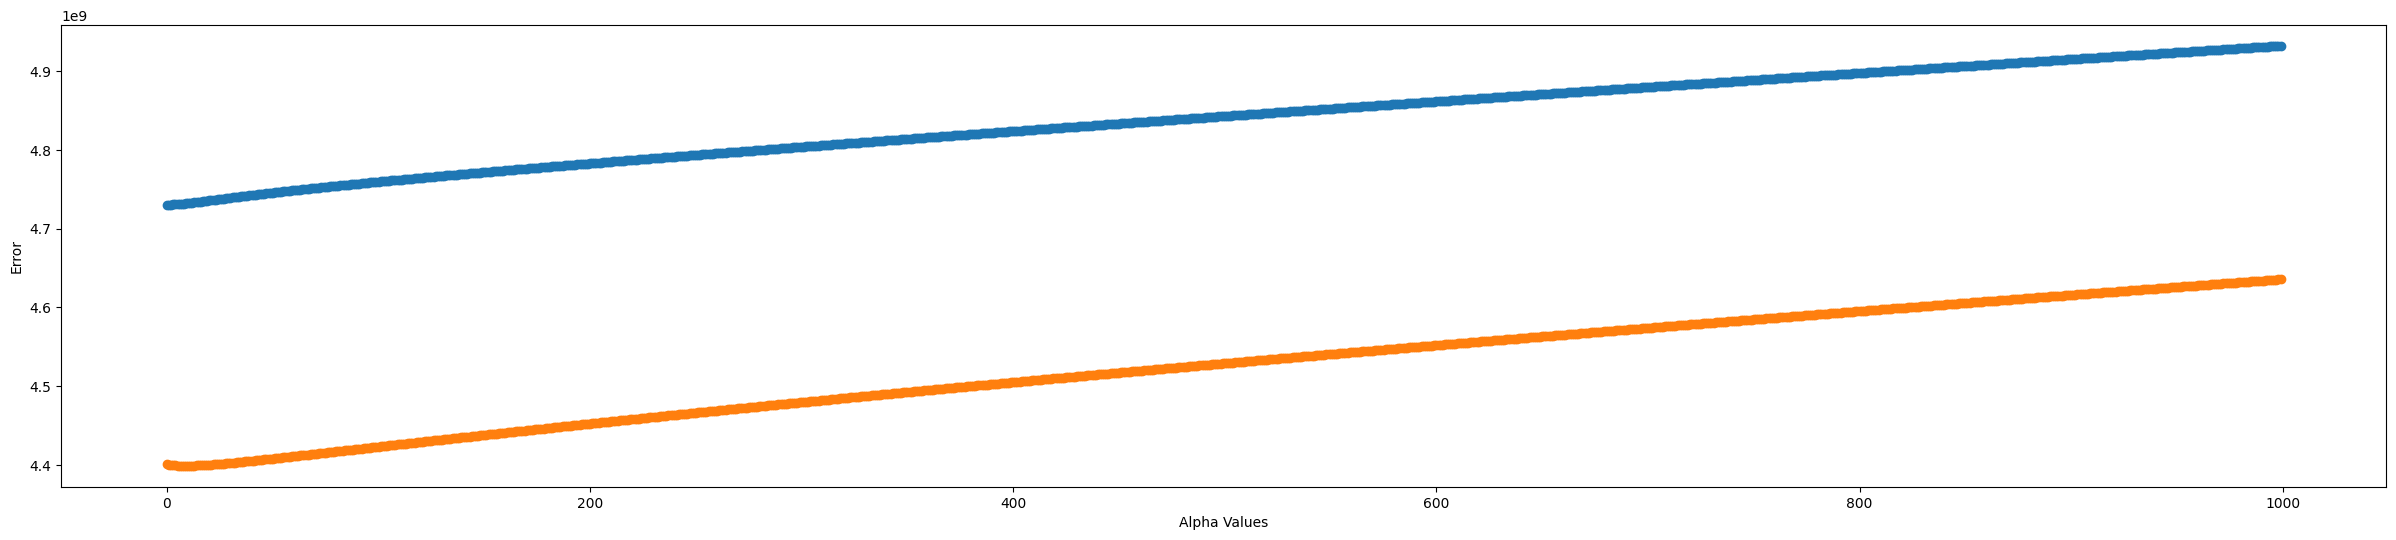

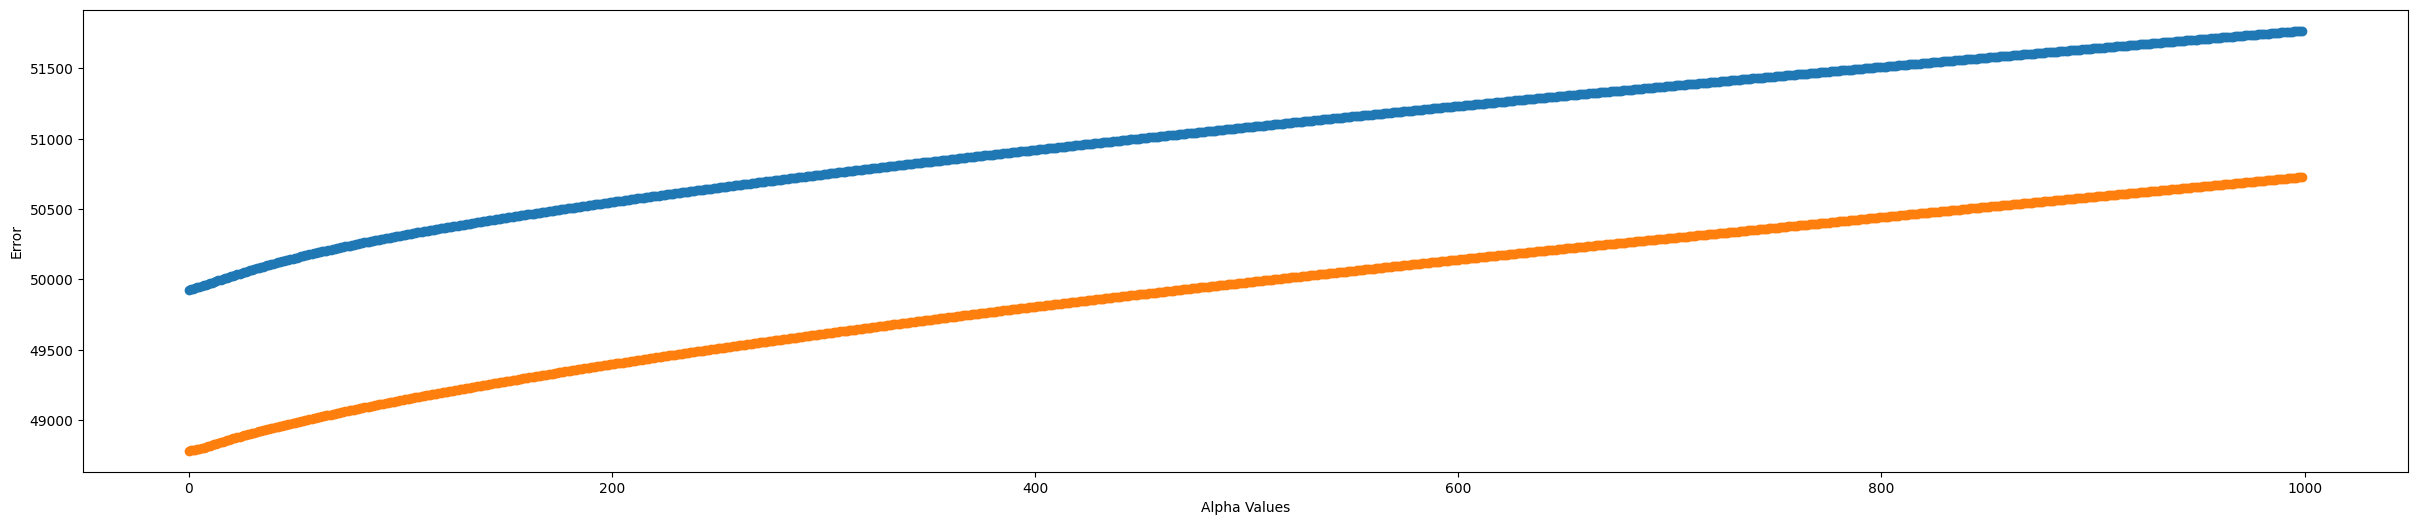

In [31]:

plot_accuracies(input_range, [mse_train_list_ridge, mse_val_list_ridge],2)
plot_accuracies(input_range, [mae_train_list_ridge, mae_val_list_ridge],2)